Hands-On Lab: K-Means Clustering    
● Step 1: Load and scale a provided dataset (numeric features only) with StandardScaler.        
● Step 2: Run K-Means for k from 1 to 10 and plot inertia to find the elbow.            
● Step 3: Compute the silhouette score for the top two candidate k values and pick the best.        
● Step 4: Fit final K-Means with the chosen k, and visualize the clusters on a 2D scatter plot.     
● Step 5: Interpret what each cluster represents in a Markdown cell     

##### Unspervised learning 

Instead of predicting a known answer,   
the goal is to discover hidden structure the data contains on its own:      
 `natural groupings`, `underlying dimensions`, or `unusual points`.

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.datasets import fetch_california_housing
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler


In [33]:
housing = fetch_california_housing(as_frame=True)

X = housing.data


##### Clustering :

**Clustering :**  groups data points so that points in the same group are similar to each other and different from points in other groups.

**--Non Scaled--**

In [23]:
km = KMeans(n_clusters=4, random_state=42, n_init=10) #  n_init dictates how many times the K-Means algorithm will initialize with different random centroid seeds before picking the best one

y_pred = km.fit_predict(X)

print("\n", y_pred)
print(km.cluster_centers_)   # the final centroid positions



 [0 2 0 ... 0 0 2]
[[ 3.92064980e+00  3.16060606e+01  5.62948780e+00  1.12247621e+00
   7.91391480e+02  2.80029877e+00  3.58433579e+01 -1.19740597e+02]
 [ 4.36687586e+00  1.27241379e+01  5.69125231e+00  1.07560677e+00
   7.73696552e+03  1.20582518e+01  3.52200000e+01 -1.19074095e+02]
 [ 3.78144439e+00  2.65983013e+01  5.17944786e+00  1.06337575e+00
   1.72203690e+03  3.06856837e+00  3.54268073e+01 -1.19421917e+02]
 [ 3.84714976e+00  2.02623574e+01  5.12964205e+00  1.06967848e+00
   3.39446116e+03  3.61811434e+00  3.51757849e+01 -1.19151874e+02]]


##### Clustering & using a pipeline:

- Always scale features before clustering   

K-Means uses distance, so an unscaled large-range feature would dominate a small-range one.

**--Scaled--**

In [ ]:

# Based on the Elbow method we got few candidate n_clusters numbers.
 # our top 2 candidates are 4 , 5 clusters

#n_clusters = 5
pipe_5 = Pipeline([('scaler',StandardScaler()) , ('model',KMeans(n_clusters=5, random_state=42))])

y_pipe_pred_5 = pipe_5.fit_predict(X)
print (y_pipe_pred_5)


#n_clusters = 3
pipe_3 = Pipeline([('scaler',StandardScaler()) , ('model',KMeans(n_clusters=3, random_state=42))])

y_pipe_pred_3 = pipe_3.fit_predict(X)
print (y_pipe_pred_3)



#n_clusters = 4
pipe = Pipeline([('scaler',StandardScaler()) , ('model',KMeans(n_clusters=4, random_state=42))])

y_pipe_pred = pipe.fit_predict(X)
print (y_pipe_pred)






# To get cluster centers , first extracting the model from the pipe then reverse transfrom the scaled cluster centers.
# used n_clusters = 4

kmeans_model =  pipe.named_steps['model'] # extracting the model from pipe
scaler = pipe.named_steps['scaler'] # extracting the scaler from pipe

scaled_cluster_centers = kmeans_model.cluster_centers_ # getting the scaled cluster centers 

original_cluster_centers = scaler.inverse_transform(scaled_cluster_centers) # reverse scaling the centers to get the original centers

print ("\nscaled_cluster_centers: ")
print (scaled_cluster_centers,"\n")


print ("original_cluster_centers: ")
print (original_cluster_centers)



[4 2 4 ... 2 2 2]
[1 1 1 ... 1 1 1]
[2 1 2 ... 1 1 1]

scaled_cluster_centers: 
[[-3.50247349e-01  2.91612611e-01 -2.96687611e-01 -7.57799656e-02
  -7.96107026e-02  8.77427327e-04 -7.78762551e-01  7.60616900e-01]
 [ 6.97618458e-02 -8.07020136e-01  1.34576984e-01  5.77131483e-03
   1.20227431e-01 -1.99029730e-02  1.07941665e+00 -9.77914643e-01]
 [-2.23296599e-01  9.94588388e-01 -1.09169442e-01 -7.23616912e-02
  -4.05806580e-01 -3.45392410e-02  1.07154686e+00 -1.18188533e+00]
 [ 1.12591019e+00 -8.24701456e-01  7.45663532e-01  2.86563560e-01
   5.35434750e-01  6.88526877e-02 -7.61542278e-01  7.96704283e-01]] 

original_cluster_centers: 
[[ 3.20527960e+00  3.23095048e+01  4.69496101e+00  1.06076307e+00
   1.33532282e+03  3.07976794e+00  3.39685020e+01 -1.18045821e+02]
 [ 4.00320286e+00  1.84829341e+01  5.76195844e+00  1.09941017e+00
   1.56162646e+03  2.86394690e+00  3.79373882e+01 -1.21528940e+02]
 [ 3.44645755e+00  4.11566327e+01  5.15890218e+00  1.06238299e+00
   9.65927296e+02  2.71193

##### the Elbow point

The elbow method runs K-Means for a range of k values and plots the inertia (total within-cluster distance) against k.
- Inertia always falls as k rises.
- The elbow point is the recommended k.


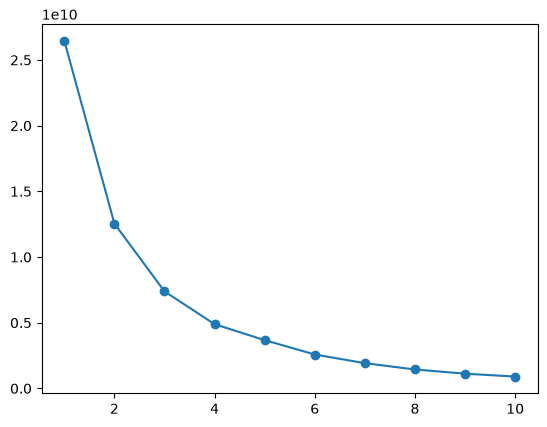

In [ ]:
inertias = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X)
    inertias.append(km.inertia_)
plt.plot(range(1, 11), inertias, marker="o")   # look for the elbow

##### silhouette_score

Measures how well each point sits inside its own cluster versus the nearest other cluster.
- a scale from -1 to +1 .
- A higher average silhouette score means better-defined clusters.

In [30]:
nonScaled_sil = silhouette_score(X,y_pred)

scaled_sil = silhouette_score(X,y_pipe_pred)

scaled_sil_3 = silhouette_score(X, y_pipe_pred_3)
scaled_sil_5 = silhouette_score(X, y_pipe_pred_5)


print(f"Non scaled data silhouette score : {nonScaled_sil:.4f}\n\n")


print(f"Scaled data 'n_clusters = 3' silhouette score : {scaled_sil_3:.4f}")
print(f"Scaled data 'n_clusters = 4' silhouette score : {scaled_sil:.4f}")
print(f"Scaled data 'n_clusters = 5' silhouette score : {scaled_sil_5:.4f}")




Non scaled data silhouette score : 0.5612


Scaled data 'n_clusters = 3' silhouette score : -0.0472
Scaled data 'n_clusters = 4' silhouette score : -0.1554
Scaled data 'n_clusters = 5' silhouette score : -0.1789


#### Visualizing k-means:

- Using scatter plot to demonstrate clustring.

California housing data has 8 dimensions(features).     
 Any scatter plot of one feature wont  give a good result since 
  K-Means used all 8 features to make its decision. 

- Instead of an abstract scatter plot, we can plot the clusters geographically to recreate a rough map of California.

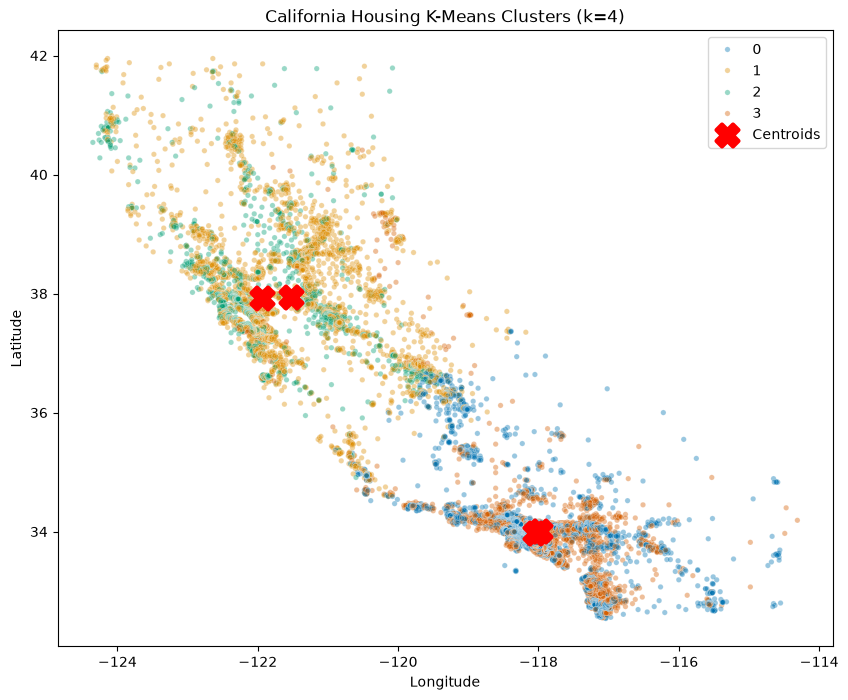

In [ ]:
# Find the column indices for plotting the centroids correctly

lon_idx = X.columns.get_loc('Longitude')
lat_idx = X.columns.get_loc('Latitude')

# Plotting
plt.figure(figsize=(10, 8))

# Plot the data points (using small size and transparency due to 20k+ rows)
sns.scatterplot(
    x=X['Longitude'], 
    y=X['Latitude'], 
    hue=y_pipe_pred, 
    palette="colorblind", 
    alpha=0.4,       
    s=15,            
    legend='full'
)

# plot cluster centers (after transforming them to non scaled version).
plt.scatter(
    original_cluster_centers[:, lon_idx], 
    original_cluster_centers[:, lat_idx], 
    color='red', 
    marker='X', 
    s=250, 
    linewidths=3, 
    label='Centroids',
    zorder=10
)

plt.title('California Housing K-Means Clusters (k=4)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.show()

##### Clusters interpetaion:

the K-Means algorithm (with $k=4$) has segmented the California neighborhoods into the following four distinct profiles:

**1. The High-Income / Coastal Hubs**   
* **Characteristics:** This cluster is defined by the highest `MedInc` (Median Income).

**2. The Outliers / Data Anomalies**
* **Characteristics:** This cluster contains a small number of districts with extreme, abnormally high values for `AveRooms`, `AveBedrms`, or `AveOccup` (Average Occupancy).

**3. Older, Established Urban Districts**
* **Characteristics:** Defined by the highest `HouseAge` alongside moderate to lower median incomes.

**4. Newer, Inland / Suburban Developments**
* **Characteristics:** Characterized by a significantly lower `HouseAge` (newer homes), average-to-low income, and geographic coordinates that push further inland.

##### PS: 
I attached a colifornia map picture to help with visualization.     
source 'https://gisgeography.com/california-map/'